# Telco Customer Churn Prediction Using Machine Learning

## Objective

Predict customers who are likely to leave a telecom service using Machine Learning.

Models used:

- Decision Tree Classifier
- Logistic Regression

The project includes:
- Exploratory Data Analysis
- Data Preprocessing
- Model Training
- Model Comparison
- Feature Importance Analysis
- Business Recommendations

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

import warnings
warnings.filterwarnings("ignore")

# Load Dataset


In [3]:
df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Initial Data Inspection

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning

In [7]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

# Exploratory Data Analysis(EDA)

#  Churn Distribution

### Observation
The dataset is imbalanced.

Most customers did not churn, while a smaller percentage left the company.

therefore, accuracy alone is not enough to evaluate the model.
Precision, recall, and F1-score are also considered.

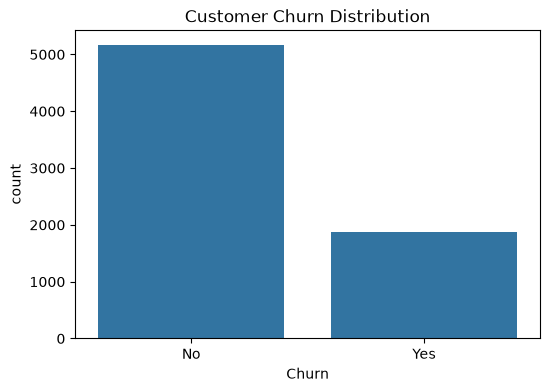

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title(
    "Customer Churn Distribution"
)

plt.show()

# Contract vs Churn

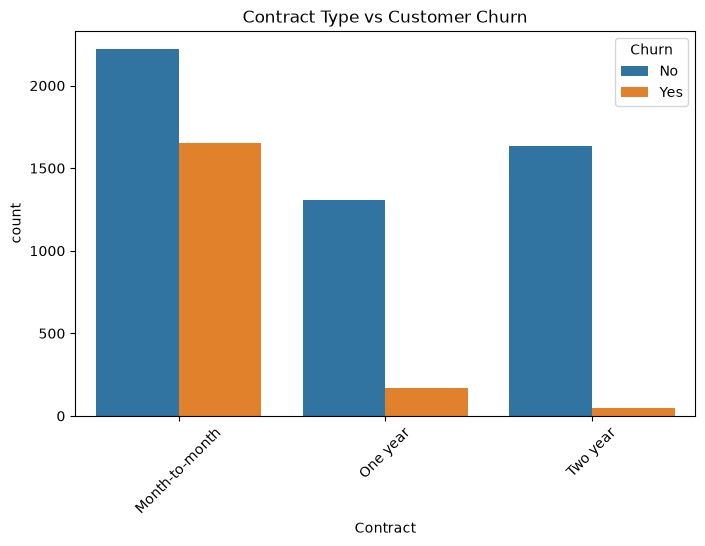

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Contract Type vs Customer Churn"
)

plt.show()

# Tenure Analysis


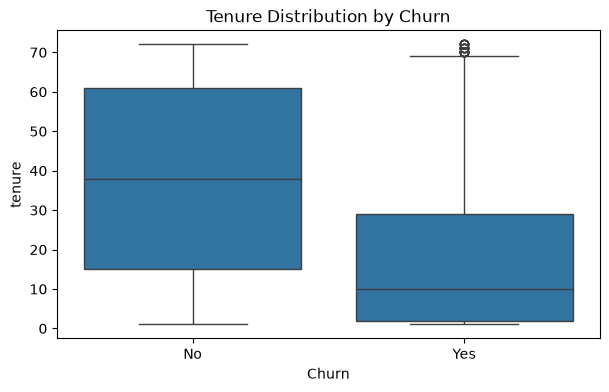

In [10]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title(
    "Tenure Distribution by Churn"
)

plt.show()

# Monthly Charges Analysis

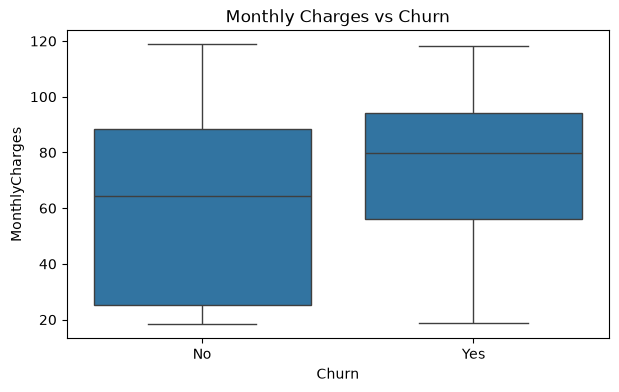

In [11]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title(
    "Monthly Charges vs Churn"
)

plt.show()

# Encode Categorical Variables

In [12]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


# Split Features and Target

In [13]:
X = df.drop(
    "Churn_Yes",
    axis=1
)


y = df["Churn_Yes"]

# Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Decision Tree Model

In [16]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)


decision_tree.fit(
    X_train,
    y_train
)
#prediction
dt_prediction = decision_tree.predict(
    X_test
)
#evaluation
print(
    classification_report(
        y_test,
        dt_prediction
    )
)


              precision    recall  f1-score   support

       False       0.85      0.79      0.82      1033
        True       0.52      0.63      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.69      1407
weighted avg       0.77      0.75      0.75      1407



# Logistic Regression


In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


logistic_model.fit(
    X_train_scaled,
    y_train
)
#predcition
lr_prediction = logistic_model.predict(
    X_test_scaled
)
#evaluation
print(
    classification_report(
        y_test,
        lr_prediction
    )
)

              precision    recall  f1-score   support

       False       0.82      0.92      0.87      1033
        True       0.67      0.43      0.53       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



# Model Comparison

In [18]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Logistic Regression"
    ],

    "Accuracy":[
        accuracy_score(y_test,dt_prediction),
        accuracy_score(y_test,lr_prediction)
    ],

    "Precision":[
        precision_score(y_test,dt_prediction),
        precision_score(y_test,lr_prediction)
    ],

    "Recall":[
        recall_score(y_test,dt_prediction),
        recall_score(y_test,lr_prediction)
    ],

    "F1 Score":[
        f1_score(y_test,dt_prediction),
        f1_score(y_test,lr_prediction)
    ]

})


results


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.745558,0.517544,0.631016,0.568675
1,Logistic Regression,0.793177,0.673640,0.430481,0.525285


# Model Comparison Graph

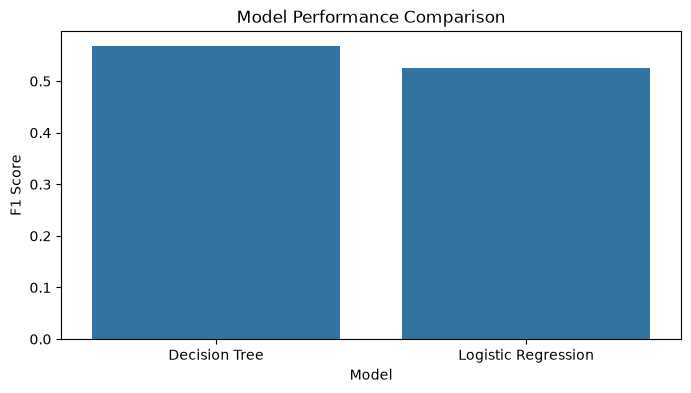

In [19]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

# Confusion Matrix

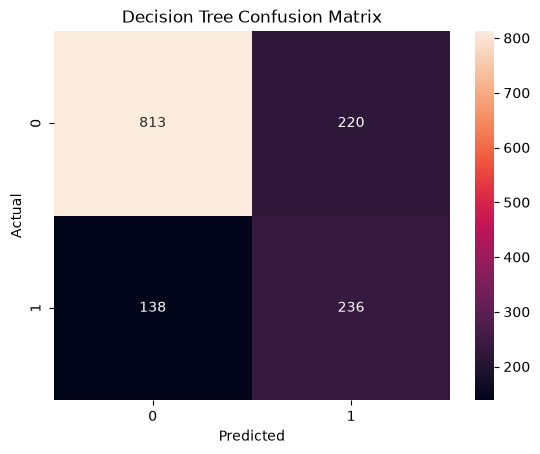

In [20]:
cm = confusion_matrix(
    y_test,
    dt_prediction
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# Feature Importance

In [21]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    decision_tree.feature_importances_

})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(10)

,Feature,Importance
7056,Contract_Two year,0.149409
7055,Contract_One year,0.099210
3,TotalCharges,0.099095
2,MonthlyCharges,0.092591
1,tenure,0.071846
7041,InternetService_Fiber optic,0.038923
7059,PaymentMethod_Electronic check,0.016473
7054,StreamingMovies_Yes,0.016026
7050,TechSupport_Yes,0.012671
7057,PaperlessBilling_Yes,0.011458


# Top 10 Feature Visualization

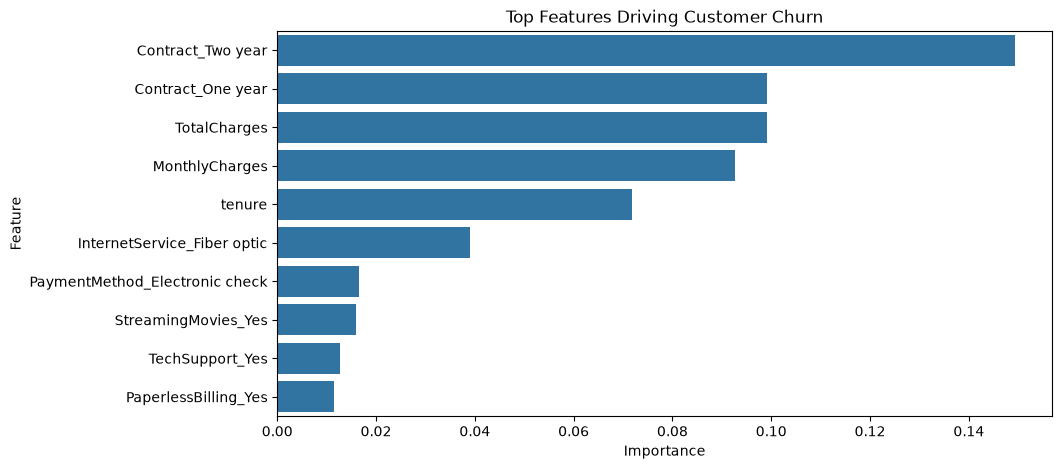

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Driving Customer Churn"
)

plt.show()

# Save Models

In [24]:
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(
    decision_tree,
    "../models/decision_tree_model.pkl"
)


joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)


print("Models saved successfully")

Models saved successfully
